In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

curr_dir = os.getcwd()
example_dir = os.path.abspath(os.path.join(curr_dir, '..'))
sys.path.append(example_dir)
root_dir = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
sys.path.append(root_dir)

import torch
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn
import kind

data_dir = '../../../data/mujoco/walker2d'
model_dir = '../../../models/mujoco/walker2d'
result_dir = '../../../results/mujoco/walker2d'

In [2]:
# --! specify kind arguments

parser = kind.create_args_parser()
args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'walker2d',
        '--data_nsample_baseline', '918',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--obs_ndim', '17',
        '--act_ndim', '6',
        '--target_ndim', '17',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '512',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '500',
        '--patience', '50',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = torch.zeros(args.target_ndim)

In [3]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[4]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 65536


In [4]:
# --! create model, dataset and training

model = kind.model(args)
dataset = example_mujoco.dataset(args, setpoint, load_normalized=True, extract_windows=False)
training = kind.training(model)

read timeseries shape is torch.Size([50, 918, 23])


In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters: {nparam/1e6}M')

number of trainable parameters: 1.849036M


### Train nominal model

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
read timeseries shape is torch.Size([27404, 48, 23])
	epoch 1 losses: train=0.964153, valid=0.701957, test=0.706233
	validation loss decreased (inf -> 0.701957), saving model ...
	epoch 2 losses: train=0.511799, valid=0.411164, test=0.412419
	validation loss decreased (0.701957 -> 0.411164), saving model ...
	epoch 3 losses: train=0.322931, valid=0.245248, test=0.244622
	validation loss decreased (0.411164 -> 0.245248), saving model ...
	epoch 4 losses: train=0.216737, valid=0.201119, test=0.201589
	validation loss decreased (0.245248 -> 0.201119), saving model ...
	epoch 5 losses: train=0.186566, valid=0.177504, test=0.178338
	validation loss decreased (0.201119 -> 0.177504), saving model ...
	epoch 6 losses: train=0.165047, valid=0.155731, test=0.156283
	validation loss decreased (0.177504 -> 0.155731), saving model ...
	epoch 7 losses: train=0.143743, valid=0.136905, test=0.137420
	validation loss decreased (0.155731 -> 0.136905), saving model ...
	epoc

In [7]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

read timeseries shape is torch.Size([27404, 48, 23])


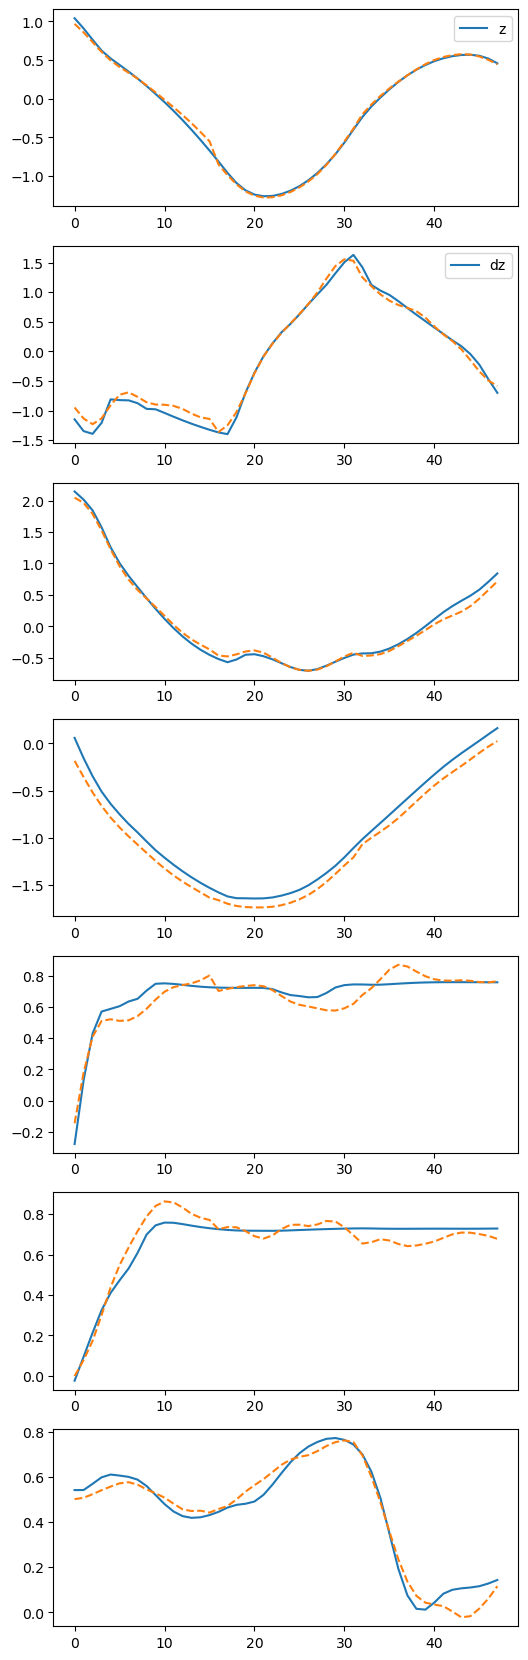

In [8]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,21))

        plt.subplot(7,1,1)
        plt.plot(true[jdata, :, 0], label='z')
        plt.plot(mean_nom[0, :, 0], linestyle='dashed')
        plt.legend()

        plt.subplot(7,1,2)
        plt.plot(true[jdata, :, 9], label='dz')
        plt.plot(mean_nom[0, :, 9], linestyle='dashed')
        plt.legend()

        plt.subplot(7,1,3)
        plt.plot(true[jdata, :, 1])
        plt.plot(mean_nom[0, :, 1], linestyle='dashed')

        plt.subplot(7,1,4)
        plt.plot(true[jdata, :, 2])
        plt.plot(mean_nom[0, :, 2], linestyle='dashed')

        plt.subplot(7,1,5)
        plt.plot(true[jdata, :, 3])
        plt.plot(mean_nom[0, :, 3], linestyle='dashed')

        plt.subplot(7,1,6)
        plt.plot(true[jdata, :, 4])
        plt.plot(mean_nom[0, :, 4], linestyle='dashed')

        plt.subplot(7,1,7)
        plt.plot(true[jdata, :, 5])
        plt.plot(mean_nom[0, :, 5], linestyle='dashed')

        plt.show()

        break

### Training nominal uncertainty

In [9]:
# --! switch to next training phase - nominal uncertainty - and train
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
read timeseries shape is torch.Size([27404, 48, 23])
read timeseries shape is torch.Size([16146, 48, 23])
	epoch 1 losses: train=0.189154, valid=0.127931, test=0.125091
	validation loss decreased (inf -> 0.127931), saving model ...
	epoch 2 losses: train=0.108304, valid=0.108358, test=0.105751
	validation loss decreased (0.127931 -> 0.108358), saving model ...
	epoch 3 losses: train=0.098714, valid=0.093703, test=0.089117
	validation loss decreased (0.108358 -> 0.093703), saving model ...
	epoch 4 losses: train=0.081774, valid=0.080490, test=0.077136
	validation loss decreased (0.093703 -> 0.080490), saving model ...
	epoch 5 losses: train=0.071958, valid=0.072159, test=0.069532
	validation loss decreased (0.080490 -> 0.072159), saving model ...
	epoch 6 losses: train=0.064580, valid=0.063774, test=0.061607
	validation loss decreased (0.072159 -> 0.063774), saving model ...
	epoch 7 losses: train=0.058039, valid=0.058274, test=0.056602
	validation l

In [10]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

read timeseries shape is torch.Size([27404, 48, 23])
read timeseries shape is torch.Size([16146, 48, 23])


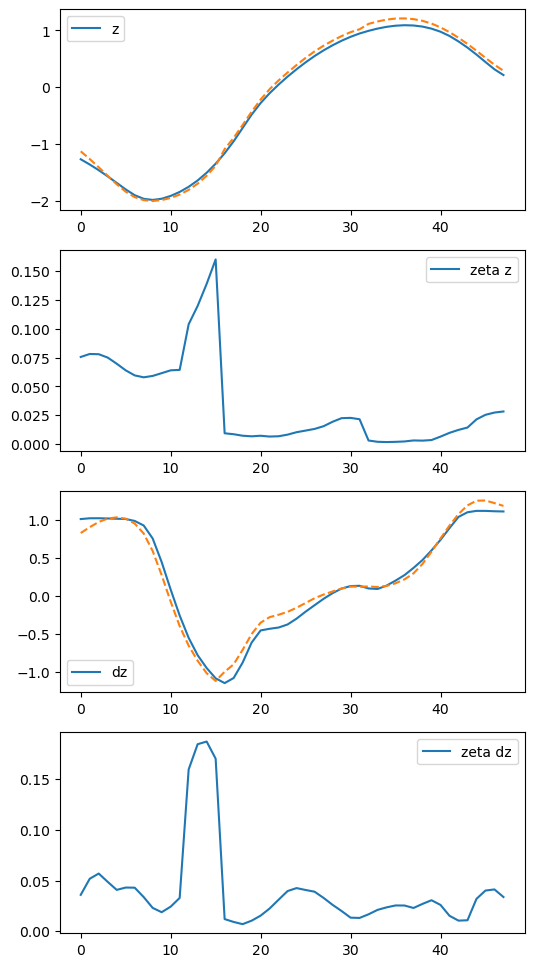

In [11]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta z')
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(zeta_nom[0, :, 6], label='zeta dz')
        plt.legend()

        plt.show()

        break

### Training excursion model

In [12]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
read timeseries shape is torch.Size([16146, 48, 23])
	epoch 1 losses: train=0.902684, valid=0.884156, test=0.889720
	validation loss decreased (inf -> 0.884156), saving model ...
	epoch 2 losses: train=0.833571, valid=0.757010, test=0.760403
	validation loss decreased (0.884156 -> 0.757010), saving model ...
	epoch 3 losses: train=0.677853, valid=0.541912, test=0.549360
	validation loss decreased (0.757010 -> 0.541912), saving model ...
	epoch 4 losses: train=0.476644, valid=0.420109, test=0.426078
	validation loss decreased (0.541912 -> 0.420109), saving model ...
	epoch 5 losses: train=0.385813, valid=0.330749, test=0.336550
	validation loss decreased (0.420109 -> 0.330749), saving model ...
	epoch 6 losses: train=0.295527, valid=0.246672, test=0.253538
	validation loss decreased (0.330749 -> 0.246672), saving model ...
	epoch 7 losses: train=0.226032, valid=0.203785, test=0.210455
	validation loss decreased (0.246672 -> 0.203785), saving model ...
	ep

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

read timeseries shape is torch.Size([16146, 48, 23])


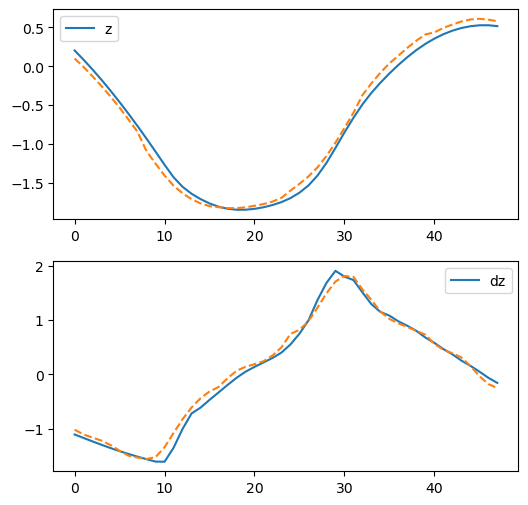

In [14]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(truth[jdata, :, 9], label='dz')
        plt.plot(mean_exc[0, :, 9], linestyle='dashed')
        plt.legend()

        plt.show()

        break

### Training excursion uncertainty

In [15]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
read timeseries shape is torch.Size([27404, 48, 23])
read timeseries shape is torch.Size([16146, 48, 23])
	epoch 1 losses: train=0.248591, valid=0.239720, test=0.244290
	validation loss decreased (inf -> 0.239720), saving model ...
	epoch 2 losses: train=0.197685, valid=0.172409, test=0.174924
	validation loss decreased (0.239720 -> 0.172409), saving model ...
	epoch 3 losses: train=0.154405, valid=0.140154, test=0.141955
	validation loss decreased (0.172409 -> 0.140154), saving model ...
	epoch 4 losses: train=0.130651, valid=0.123104, test=0.124599
	validation loss decreased (0.140154 -> 0.123104), saving model ...
	epoch 5 losses: train=0.119378, valid=0.114764, test=0.116073
	validation loss decreased (0.123104 -> 0.114764), saving model ...
	epoch 6 losses: train=0.113126, valid=0.109426, test=0.110774
	validation loss decreased (0.114764 -> 0.109426), saving model ...
	epoch 7 losses: train=0.106520, valid=0.101611, test=0.102909
	validation

In [16]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

read timeseries shape is torch.Size([27404, 48, 23])
read timeseries shape is torch.Size([16146, 48, 23])


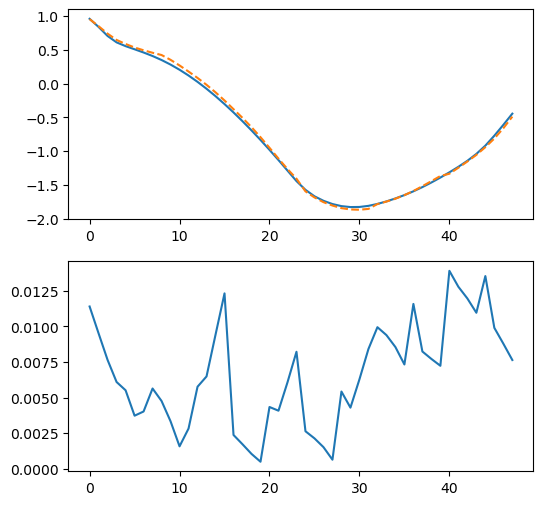

In [17]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc
        zeta_exc = model_o.zeta_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(true[jdata, :, :1])
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_exc[0, :, :1])

        plt.show()

        break

### Evaluating KIND blending

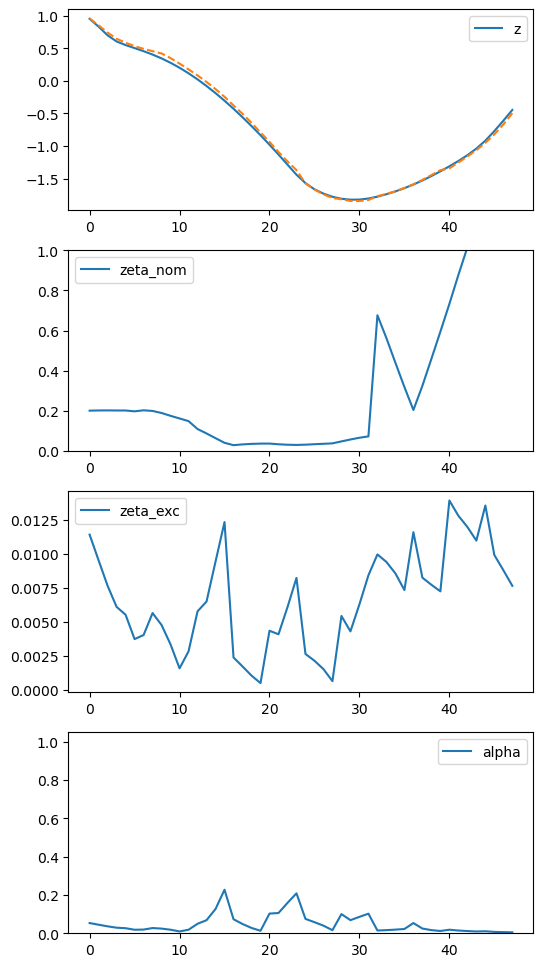

In [18]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pred = model_o.blend
        zeta_nom = model_o.zeta_nom
        zeta_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(pred[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(zeta_exc[0, :, :1], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :1], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break